In [3]:
import pyomo.environ as pyo
from pyomo.environ import *
from pyomo.opt import SolverFactory
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

In [4]:
def gettingDataFromExcel(fileName):
    data1 = pd.read_excel(fileName, sheet_name="data")
    cities = data1["city"].tolist()
    interest = data1["interest"].tolist()
    cost = data1["cost"].tolist()

    data2 = pd.read_excel(fileName, sheet_name="time_matrix", index_col=0)
    time_matrix = data2.loc[cities, cities].values

    return cities, interest, cost, time_matrix

In [5]:
def create_optw_model(cities, interest, cost, time_matrix, budget, cost_pass, insur_cost, tot_days, max_travel_days, lambda_, alpha,max_days_per_city):
    num_cities = len(cities)
    model = ConcreteModel()
    model.Cities = RangeSet(1, num_cities)

    # Decision variables
    model.y = Var(model.Cities, model.Cities, within=Binary)  # route from i to j
    model.x = Var(model.Cities, within=NonNegativeIntegers)      # days in city i
    model.z = Var(model.Cities, within=Binary)                # 1 if city i visited
    model.g = Var(within=NonNegativeIntegers)                    # travel days
    model.u = Var(model.Cities, within=NonNegativeReals, bounds=(0, num_cities - 1))  # MTZ position

    # Objective: maximize utility - penalty + incentive for visiting more cities
    model.obj = Objective(
        expr=sum(interest[i-1] * model.x[i] for i in model.Cities)
           + alpha * sum(model.z[i] for i in model.Cities)
           - lambda_ * sum(time_matrix[i-1][j-1] * model.y[i, j]
                           for i in model.Cities for j in model.Cities if i != j),
        sense=maximize
    )

    # Total time constraint
    model.total_days = Constraint(expr=sum(model.x[i] for i in model.Cities) + model.g <= tot_days)

    # Max travel days
    model.travel_days = Constraint(expr=model.g <= max_travel_days)

    # Budget constraint
    model.budget_max = Constraint(expr=sum(cost[i-1] * model.x[i] for i in model.Cities) + cost_pass + insur_cost <= budget)

    # Visit logic: if visited, at least 1 day; if not visited, 0 days
    model.visiting = ConstraintList()
    for i in model.Cities:
        model.visiting.add(model.x[i] <= 30 * model.z[i])
        model.visiting.add(model.x[i] >= model.z[i])  # at least 1 day if visited
        model.visiting.add(model.x[i] <= model.z[i]*max_days_per_city)

    # Flow constraints (in = out = z[i]) and no self-loops
    model.flow = ConstraintList()
    for i in model.Cities:
        model.flow.add(sum(model.y[i, j] for j in model.Cities if j != i) == model.z[i])
        model.flow.add(sum(model.y[j, i] for j in model.Cities if j != i) == model.z[i])
        model.flow.add(model.y[i, i] == 0)

    # Depart from and return to Milan (city 1)
    model.departure = Constraint(expr=sum(model.y[1, j] for j in model.Cities if j != 1) == 1)
    model.returns = Constraint(expr=sum(model.y[j, 1] for j in model.Cities if j != 1) == 1)

    # Number of arcs must equal number of travel days
    model.routes = Constraint(expr=sum(model.y[i, j] for i in model.Cities for j in model.Cities) == model.g)

    # Subtour elimination (MTZ constraints)
    model.subtour_constraints = ConstraintList()
    model.subtour_constraints.add(model.u[1] == 0)  # start from Milan
    for i in model.Cities:
        for j in model.Cities:
            if i != j and i != 1 and j != 1:
                model.subtour_constraints.add(
                    model.u[i] + 1 <= model.u[j] + (num_cities - 1) * (1 - model.y[i, j])
                )

    # Link between route and city visit
    model.y_z_link = ConstraintList()
    for i in model.Cities:
        for j in model.Cities:
            if i != j:
                model.y_z_link.add(model.y[i, j] <= model.z[i])
                model.y_z_link.add(model.y[i, j] <= model.z[j])

    return model

In [ ]:
df = pd.read_excel('C:\\Users\\marti\\OneDrive\\Desktop\\opt_project.xlsx')
print(df.head())

   Nodes     city  interest  cost
0      0   Milano      4.61   155
1      1  Lisbona      4.37   130
2      2    Porto      4.52   100
3      3     Faro      4.19   120
4      4  Coimbra      4.50   110


In [ ]:
# Parametri
cost_pass = 286
insur_cost = 55
budget = 2500
tot_days = 30
max_travel_days = 7
lambda_ = 0.02
alpha = 3
fileName = "C:\\Users\\marti\\OneDrive\\Desktop\\opt_project.xlsx"
max_days_per_city = 5


cities, interest, cost, time_matrix = gettingDataFromExcel(fileName)

In [9]:
print("Cities:", cities)
print("Interest:", interest)
print("Cost:", cost)
print("Time matrix shape:", time_matrix.shape)

Cities: ['Milano', 'Lisbona', 'Porto', 'Faro', 'Coimbra', 'Fatima', 'Madrid', 'Barcellona', 'Saragozza', 'Valencia', 'Siviglia', 'Venezia', 'Roma', 'Firenze', 'Napoli', 'Parigi', 'Lione', 'Nizza', 'Bordeaux', 'Tolosa']
Interest: [4.61, 4.37, 4.52, 4.19, 4.5, 4.59, 4.6, 4.55, 4.56, 4.46, 4.7, 4.58, 4.56, 4.59, 4.68, 4.62, 4.58, 4.53, 4.35, 4.29]
Cost: [155, 130, 100, 120, 110, 100, 130, 150, 100, 110, 110, 155, 145, 135, 110, 155, 110, 130, 110, 100]
Time matrix shape: (20, 20)


In [ ]:
# Crea e risolvi
model = create_optw_model(cities, interest, cost, time_matrix, budget, cost_pass, insur_cost, tot_days, max_travel_days, lambda_, alpha,max_days_per_city)
solver = SolverFactory("glpk")
results = solver.solve(model, tee=True, timelimit=60) #poi aumentare il tempo


GLPSOL--GLPK LP/MIP Solver 5.0
Parameter(s) specified in the command line:
 --tmlim 60 --write /tmp/tmpiaehfh1d.glpk.raw --wglp /tmp/tmpocxss2z1.glpk.glp
 --cpxlp /tmp/tmp9ygl0lr6.pyomo.lp
Reading problem data from '/tmp/tmp9ygl0lr6.pyomo.lp'...
/tmp/tmp9ygl0lr6.pyomo.lp:8568: warning: lower bound of variable 'x22' redefined
/tmp/tmp9ygl0lr6.pyomo.lp:8568: warning: upper bound of variable 'x22' redefined
1229 rows, 461 columns, 3968 non-zeros
441 integer variables, 420 of which are binary
8988 lines were read
Writing problem data to '/tmp/tmpocxss2z1.glpk.glp'...
7289 lines were written
GLPK Integer Optimizer 5.0
1229 rows, 461 columns, 3968 non-zeros
441 integer variables, 420 of which are binary
Preprocessing...
20 constraint coefficient(s) were reduced
1207 rows, 440 columns, 3926 non-zeros
421 integer variables, 400 of which are binary
Scaling...
 A: min|aij| =  1.000e+00  max|aij| =  1.550e+02  ratio =  1.550e+02
GM: min|aij| =  6.687e-01  max|aij| =  1.495e+00  ratio =  2.236e+00

In [11]:
solution = []
for i in model.Cities:
    for j in model.Cities:
        if i != j and pyo.value(model.y[i, j]) > 0.5:
            solution.append((cities[i-1], cities[j-1]))
def reOrderPath(solution, Nodes):
    Depot = Nodes[0]
    DepotReturn = Nodes[0]  # supponiamo ritorno alla città iniziale
    node = Depot
    solutionOrdered = []
    solutionPointsOrdered = []

    while node != DepotReturn or not solutionPointsOrdered:
        solutionPointsOrdered.append(node)
        found = False
        for arc in solution:
            a, b = arc
            if a == node:
                solutionOrdered.append(arc)
                node = b
                found = True
                break
        if not found:
            break  # evita loop infinito in caso di errore nei dati

    solutionPointsOrdered.append(DepotReturn)
    return solutionOrdered, solutionPointsOrdered

# Ordina il percorso
ordered_arcs, ordered_cities = reOrderPath(solution, cities)

# Stampa città visitate con giorni di permanenza
print("\n--- Sequenza delle città con giorni di permanenza ---")
for city in ordered_cities[:-1]:  # saltiamo l'ultima Milano ripetuta
    idx = cities.index(city) + 1  # pyomo usa indice da 1
    days = round(pyo.value(model.x[idx]))
    print(f"{city} ({days} giorn{'i' if days > 1 else 'o'})")

print("\n--- Archi ordinati del percorso ---")
for arc in ordered_arcs:
    print(f"{arc[0]} → {arc[1]}")

print("\n--- Sequenza completa delle città ---")
print(" → ".join(ordered_cities))


--- Sequenza delle città con giorni di permanenza ---
Milano (1 giorno)
Nizza (1 giorno)
Saragozza (5 giorni)
Barcellona (1 giorno)
Madrid (1 giorno)
Tolosa (5 giorni)
Lione (5 giorni)

--- Archi ordinati del percorso ---
Milano → Nizza
Nizza → Saragozza
Saragozza → Barcellona
Barcellona → Madrid
Madrid → Tolosa
Tolosa → Lione
Lione → Milano

--- Sequenza completa delle città ---
Milano → Nizza → Saragozza → Barcellona → Madrid → Tolosa → Lione → Milano


In [12]:

def plot_interrail_graph_with_milano(model, cities):
    G = nx.DiGraph()
    edges = []

    start_city = cities[0]  # Milano è la prima della lista

    for i in model.Cities:
        for j in model.Cities:
            if i != j and pyo.value(model.y[i, j]) == 1:
                city_i = cities[i - 1]
                city_j = cities[j - 1]
                G.add_edge(city_i, city_j)
                edges.append((city_i, city_j))

    # Layout leggibile
    pos = nx.spring_layout(G, seed=42)

    plt.figure(figsize=(12, 8))

    # Colori: Milano in rosso, le altre in azzurro
    node_colors = ['lightgreen' if city == start_city else 'lightblue' for city in G.nodes()]

    # Disegno grafo
    nx.draw(G, pos,
            with_labels=True,
            node_size=3000,
            node_color=node_colors,
            font_size=10,
            font_weight='bold',
            arrows=True,
            arrowsize=20)

    plt.title("Percorso Ottimale Interrail (partenza/arrivo: Milano)", fontsize=14)
    plt.axis('off')
    plt.show()

    return edges

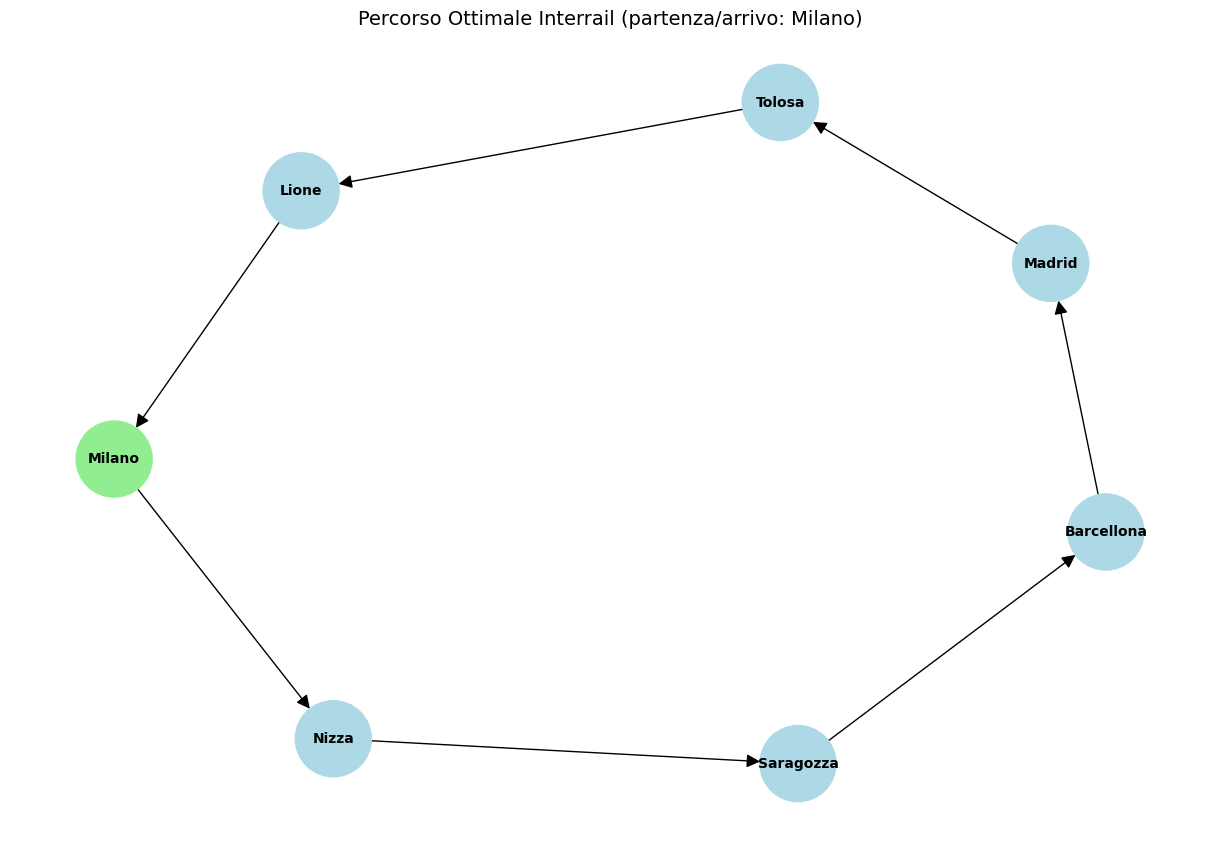

In [13]:
edges = plot_interrail_graph_with_milano(model, cities)
